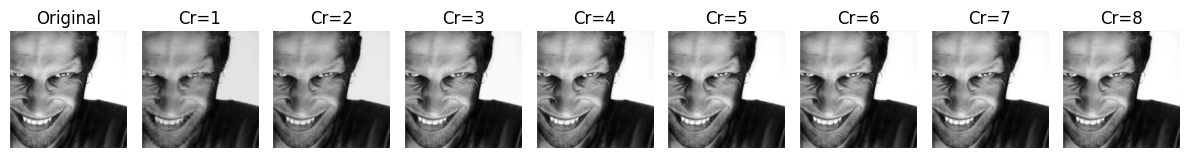

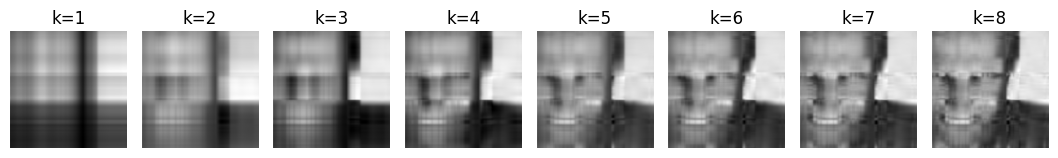

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img_path='RDJ-256.jpeg'

# Adapted from professor provided example code
def svd_blur(image_path, k_values=[5, 20, 50, 100]):
    # Load image and convert to grayscale
    img = Image.open(image_path).convert('L') # 'L' = Greyscale
    A = np.array(img, dtype=np.float64)
#    print(len(k_values))
    # Apply SVD
    U, S, VT = np.linalg.svd(A, full_matrices=False)

    # Plot original
    plt.figure(figsize=(12,3))
    plt.subplot(1, len(k_values)+1, 1)
    plt.imshow(A, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Reconstruct with different k
    for idx, k in enumerate(k_values, start=1):
        Ak = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
        plt.subplot(1, len(k_values)+1, idx)
        plt.imshow(Ak, cmap='gray')
        plt.title(f'k={k}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

### I am leaving this dealing whatever the k --> k_values thing is ...###

def preprocess(image_path):
    img = Image.open(image_path).convert('L')
    img = img.resize((256,256))
    A = np.array(img, dtype=np.float64)
    return A

def compress_block(block, k):
    # Apply SVD
    U, S, VT = np.linalg.svd(block, full_matrices=False)
    # Reconstruct from top k values
    compressed_block = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]   
    return compressed_block
    
def svd_blockwise(img, k, block_size=8):
    h, w = img.shape
    compressed_img = np.zeros_like(img)
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            compressed_img[i:i+block_size, j:j+block_size] = compress_block(img[i:i+block_size, j:j+block_size], k)

    return compressed_img
    
def image_compression(image_path, block_size=8, k_values=[5, 20, 50, 100]):
    # Saving original after preprocessing to ensure pipeline consistency
    img = preprocess(image_path)
    Image.fromarray(img).convert("L").save('CompImg-0.jpg')
    
    # Plot original
    plt.figure(figsize=(12,3))
    plt.subplot(1, len(k_values)+1, 1)
    plt.imshow(img, cmap="gray")
    plt.title('Original')
    plt.axis('off')
    
    for idx, k in enumerate(k_values, start = 2):
        compressed_img = svd_blockwise(img, k, block_size)
        Image.fromarray(compressed_img).convert("L").save(f'CompImg-{block_size}x{block_size}-{k}.jpg')
        plt.subplot(1, len(k_values)+1, idx)
        plt.imshow(compressed_img, cmap='gray')
        plt.title(f'Cr={k}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
        


def blocking_test(image_path):
    img = preprocess(image_path)
    h, w = img.shape
    rearranged_img = np.zeros_like(img)
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            rearranged_img[j:j+8, i:i+8] = img[i:i+8, j:j+8]

    plt.imshow(rearranged_img, cmap="gray")
    plt.axis('off')

#blocking_test(img_path)

#proc_img = preprocess('RDJ-256.jpeg')

#comp_img = svd_blockwise(proc_img, k_values=[1,2,3,4,5,6,7,8])

image_compression(img_path, k_values=[1,2,3,4,5,6,7,8])

#plt.imshow(comp_img, cmap='gray')
    
# Example usage
svd_blur('RDJ-256.jpeg', k_values=[1,2,3,4,5,6,7,8])

